## Multi-day Orbit Dataset Evaluation

The objective of this script is the following:

1. Prepare the dataset: we are considering both V2 and V4 datasets
2. Train the model on data from V2
3. Evaluate enrollment (V2) and identification (V4), using a subset of devices:

We're going to be using the following set of nodes:
* Training: [] 
* Testing:  [269, 398, 280, 315, 394, 300, 330]

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import matlab
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI
from extractor_api import ExtractorAPI
from evaluation_api import EvaluationAPI
from fingerprinting_api import FingerprintingAPI
import random
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

os.environ['TF_DETERMINISTIC_OPS'] = '1'

2024-10-29 16:49:05.425244: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-29 16:49:05.425305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-29 16:49:05.426149: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-29 16:49:05.433094: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-29 16:49:06.158910: W tensorflow/compiler/tf2

In [2]:
DATASET_NAME =           DatasetAPI.DATASET_WISIG
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_workflow'
AUG_ON =                 False

DATA_CONFIG = {
    'dataset_name':      DATASET_NAME,
    'frame_count_train': 500, # 200 for v2, 500 for v3 -- for our data
    # 'frame_count_train': 1000, # 200 for v2, 500 for v3 -- for WiSig
    'frame_count_epoch': 100, # across how many frames to average fingerprints
    'samples_count':     400
}

AUG_CONFIG = {
    'multiplier':        5,
    't_rms_bounds':      matlab.double([1, 2]),
    'd_f_bounds':        matlab.double([0, 1]),
    'k_factor_bounds':   matlab.double([0, 1]),
    'awgn':              matlab.double([0, 1]),
}

MODEL_CONFIG = {
    'batch_size':        32,
    'loss_type':         'triplet_loss', 'alpha': 0.5,
    # 'loss_type':         'quadruplet_loss', 'alpha': 1.1,
    'patience':          10,
    'fp_len':            512,
    # 'row':               50,
    'row':               100,
    'enable_ind':        True
}

RX_NODES = [DatasetAPI.RX_1]

In [ ]:
extractor_api = ExtractorAPI()
dataset_api = DatasetAPI(
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
fp_api = FingerprintingAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG,
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)
eval_api = EvaluationAPI(
    rx_ids = RX_NODES, 
    data_config=DATA_CONFIG, 
    aug_config=AUG_CONFIG, 
    model_config=MODEL_CONFIG, 
    root_dir=ROOT_DIRECTORY, 
    matlab_src_dir=MATLAB_SRC_DIRECTORY, 
    matlab_session_id=MATLAB_SESSION_ID, 
    aug_on=AUG_ON)

In [4]:
enable_training = True

if enable_training: models, histories = fp_api.train_models()
else: models = fp_api.load_models()

model = models[RX_NODES[0]]
history = histories[RX_NODES[0]]

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Devices for training: 33
Devices for testing: 6
Combining training & testing data, since we're working with WiSig.
Data before filtering: (22500, 400)
Label before filtering: (22500, 1)
Data after filtering: (16500, 400)
Label after filtering: (16500, 1)
(16500, 400)


2024-10-29 16:49:33.986650: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 77400 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2024-10-29 16:49:33.988242: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 77976 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:04:00.0, compute capability: 8.0
2024-10-29 16:49:33.989730: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 77980 MB memory:  -> device: 2, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:43:00.0, compute capability: 8.0


Epoch 1/1000


2024-10-29 16:49:36.413743: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8905
2024-10-29 16:49:38.125232: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fb165204690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-29 16:49:38.125291: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-29 16:49:38.125300: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-29 16:49:38.125308: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2024-10-29 16:49:38.133141: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1730234978.258488 2972900 device_compi

108/464 [=====>........................] - ETA: 8s - loss: 0.0738

KeyboardInterrupt: 

Devices for training: 25
Devices for testing: 7
Great! Epoch #1 and epoch #2 contain identical sets of device IDs. We can perform closed-set evaluation.
(700, 1000)
(700, 1000)


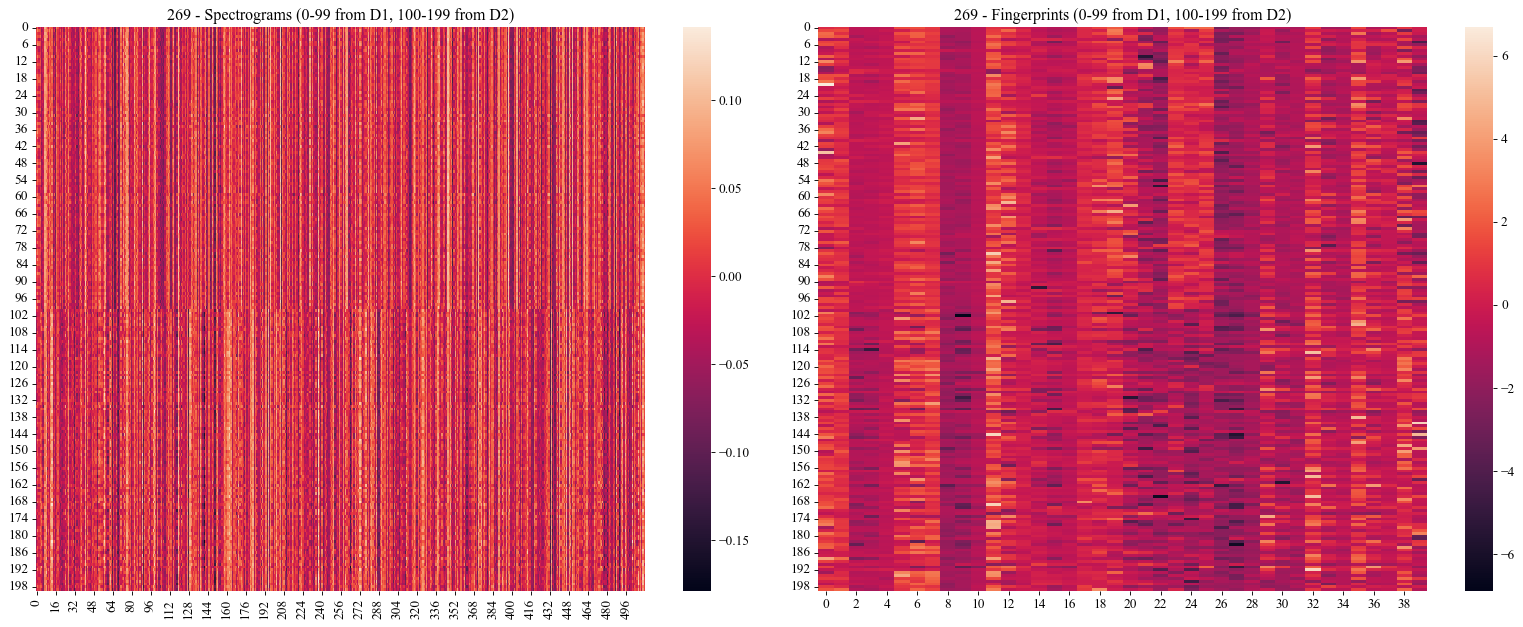

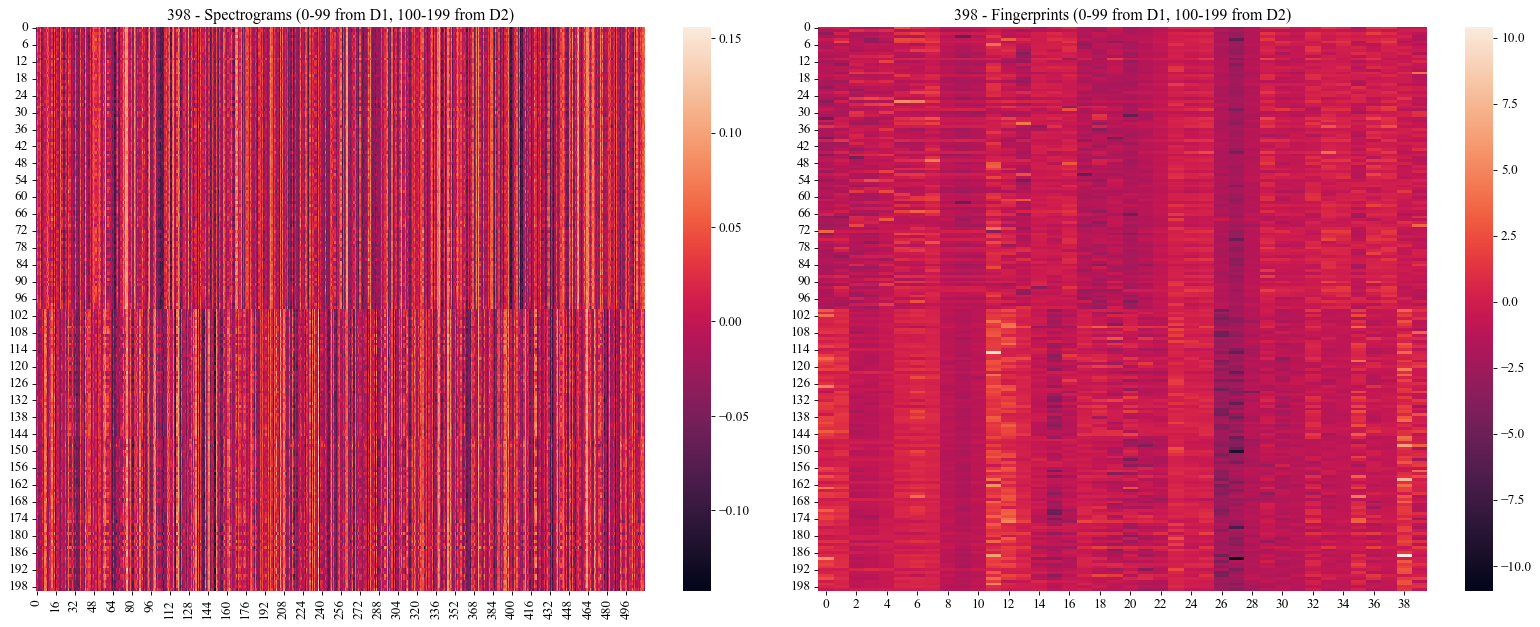

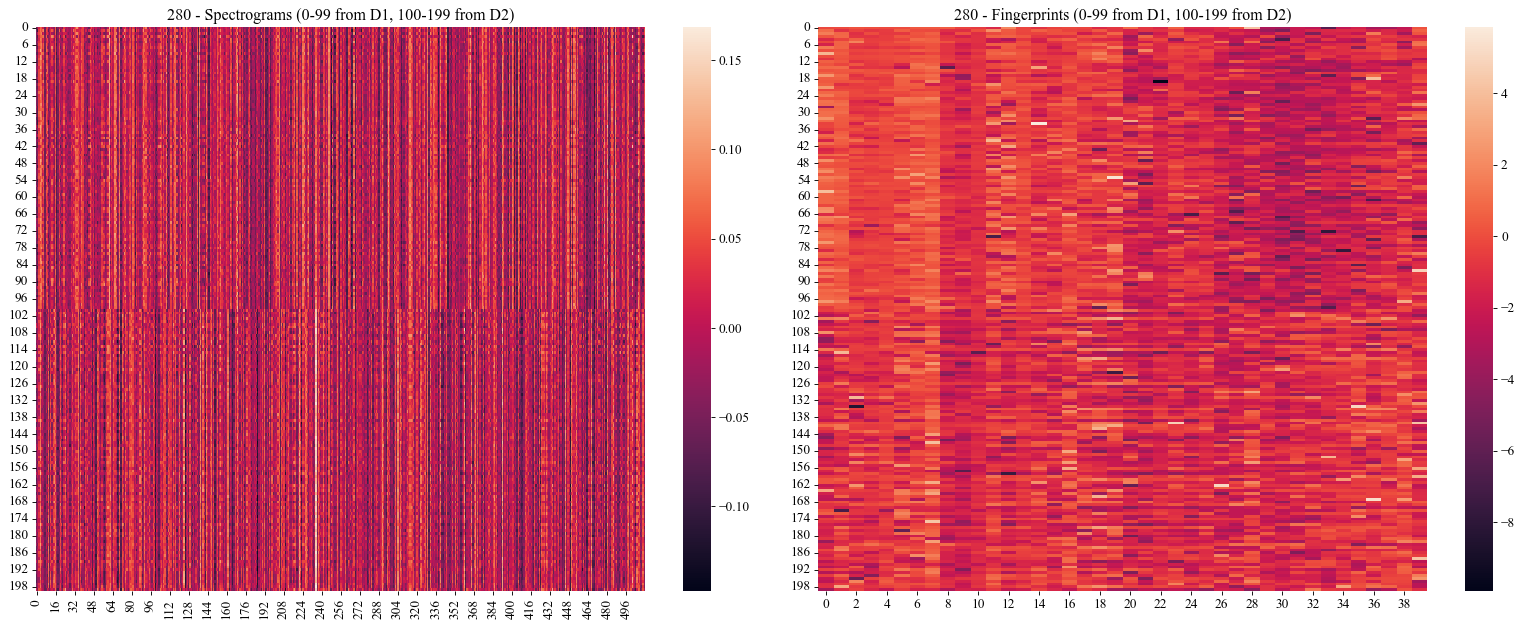

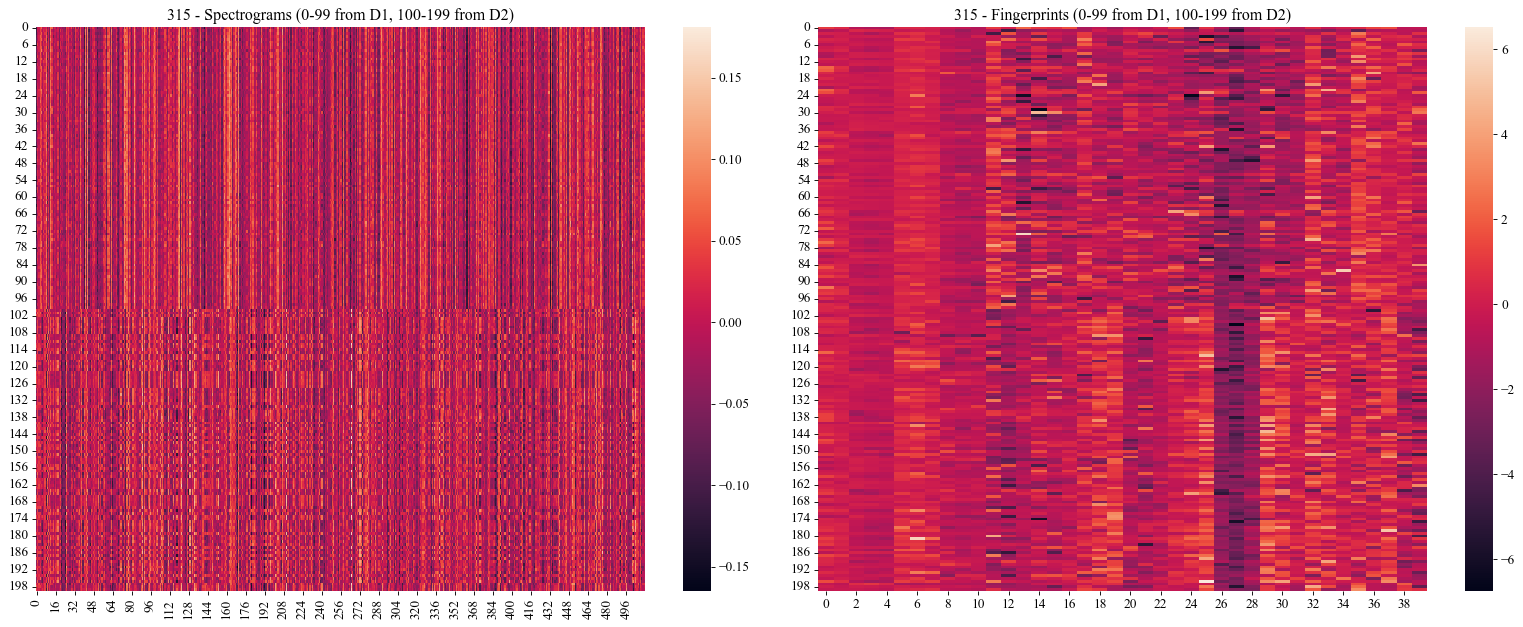

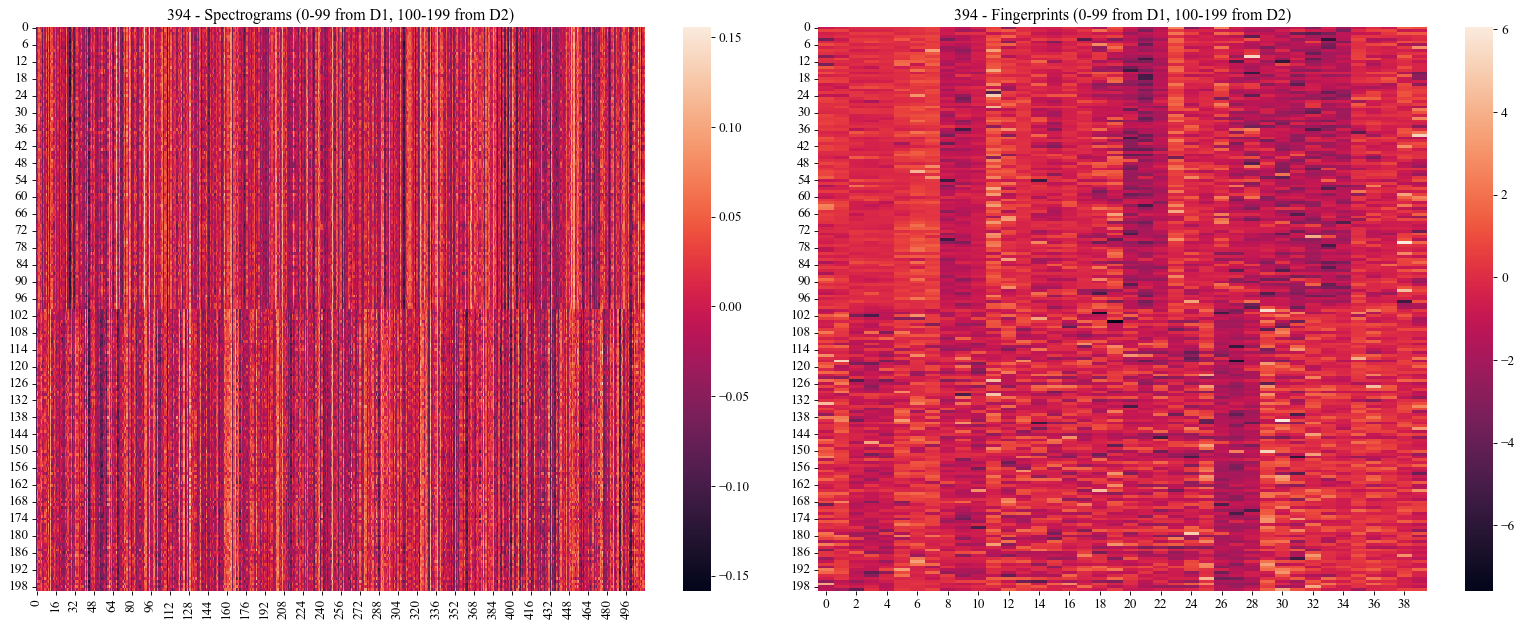

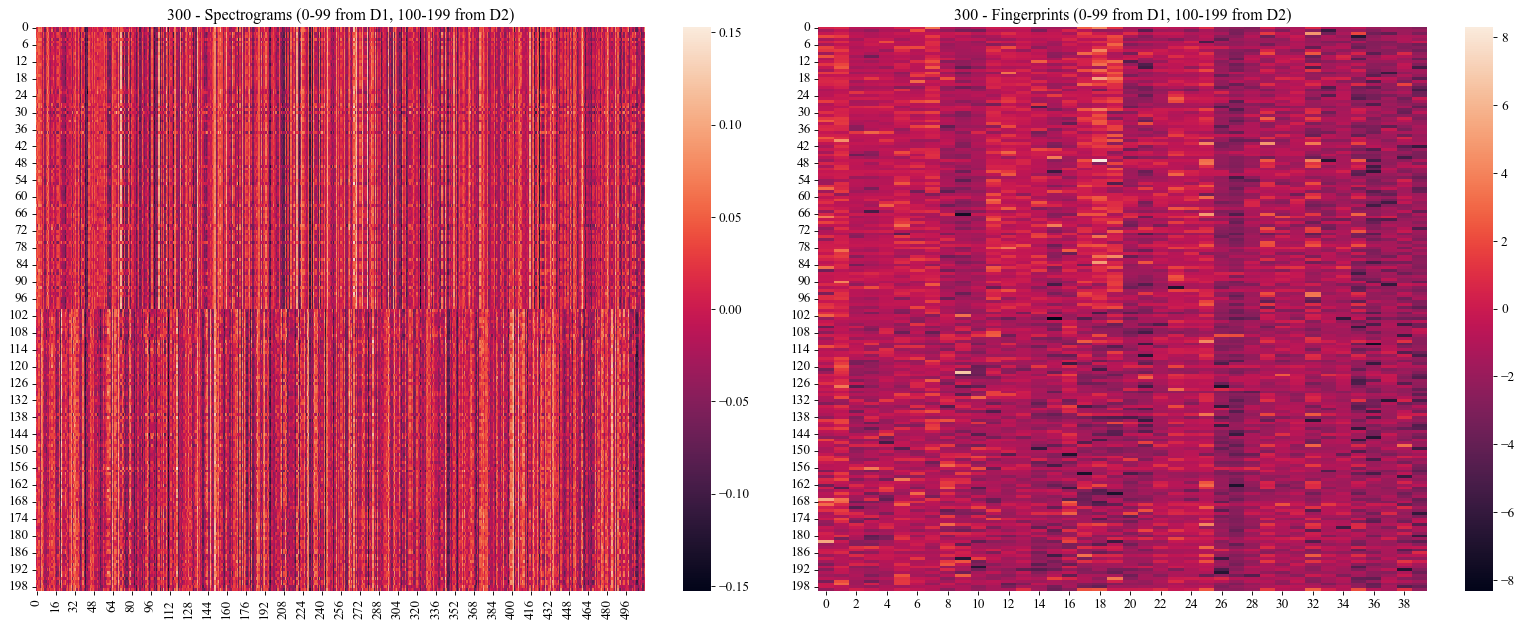

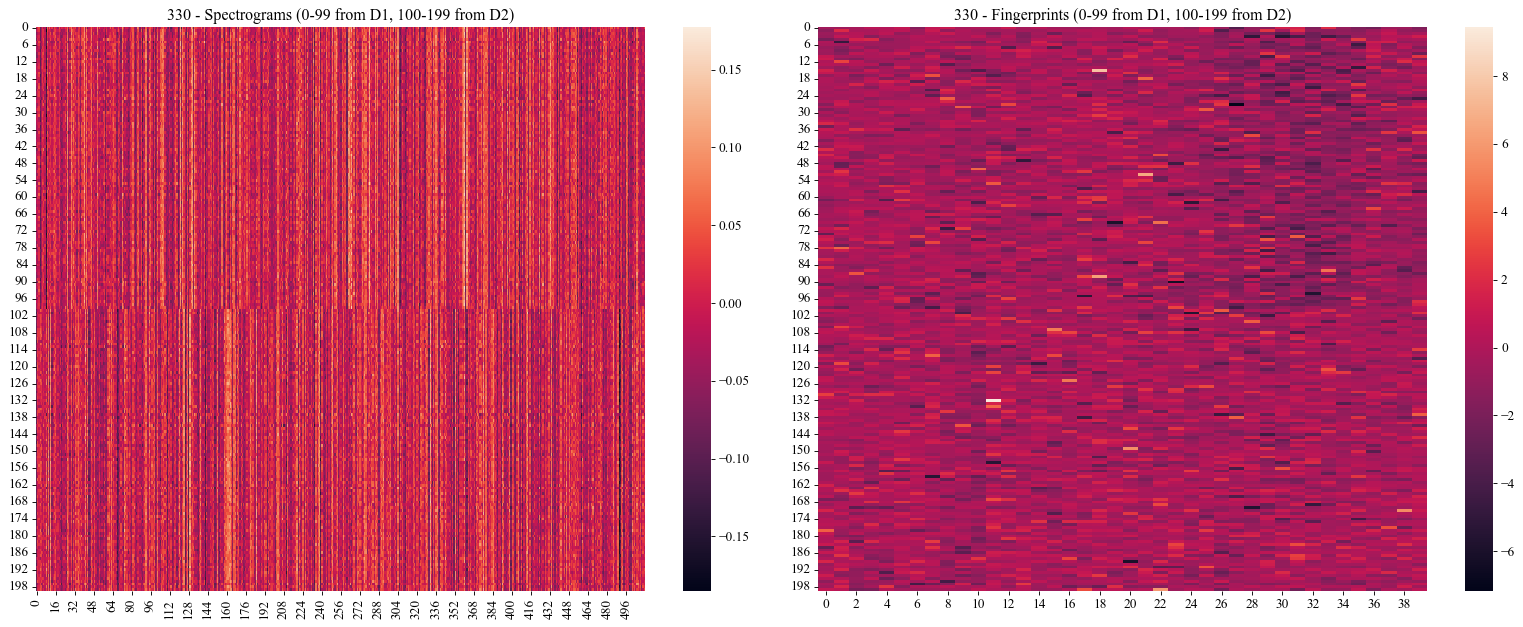

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


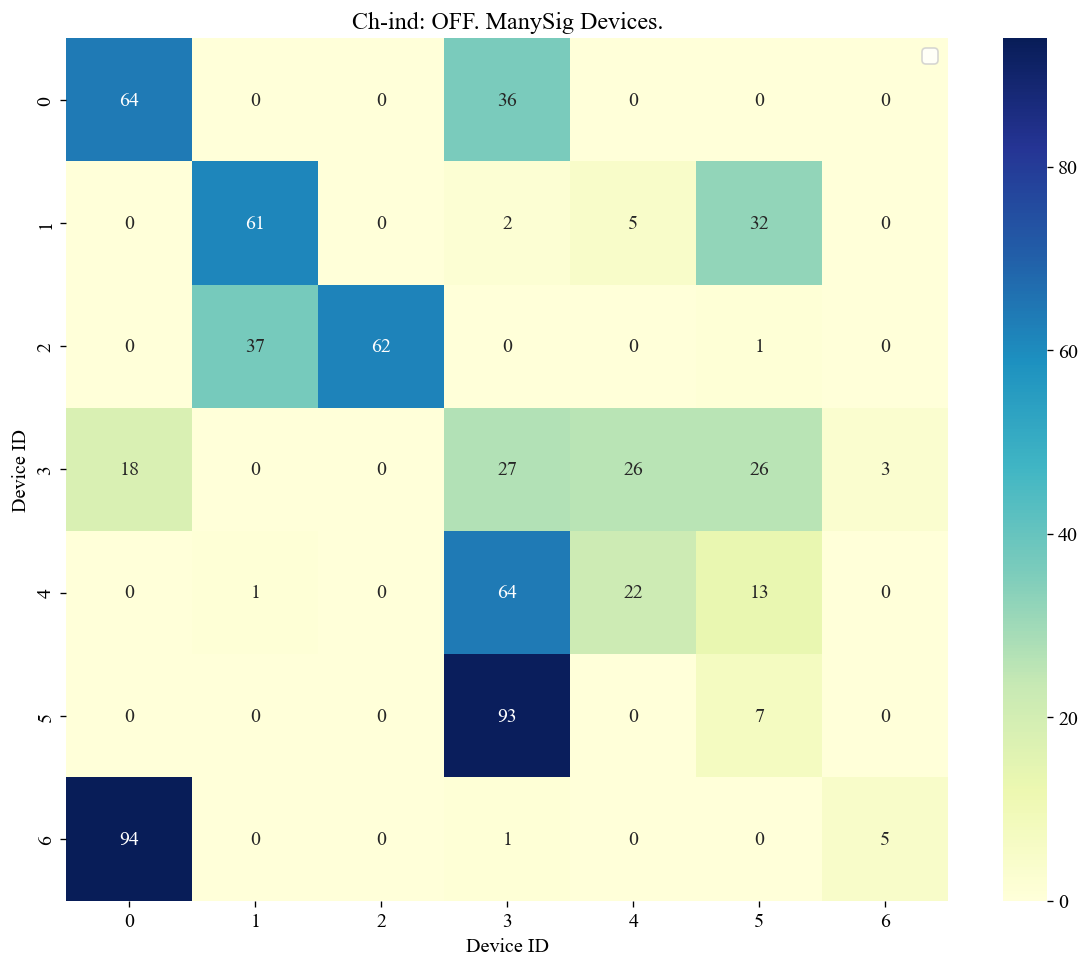

Closed-set classification accuracy: 35.43%


In [12]:
def shuffle(data, label):
    new_order = np.arange(label.shape[0])
    np.random.shuffle(new_order)
    data = data[new_order, :]
    label = label[new_order]
    return data, label

# 1. Retrieve information about the WiSig dataset (device IDs, paths, etc)
_, dataset_epoch_paths, _, _, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None)

data_enroll, label_enroll, _ = dataset_api.load_raw_dataset(dataset_epoch_paths[0], shuffle=False)
data_enroll, label_enroll, _ = dataset_api.filter_dataset(data_enroll, label_enroll, None, dev_range=node_ids_epoch, pkt_range=np.arange(0, 100))
data_enroll, label_enroll = shuffle(data_enroll, label_enroll)

data_id, label_id, _ = dataset_api.load_raw_dataset(dataset_epoch_paths[1], shuffle=False)
data_id, label_id, _ = dataset_api.filter_dataset(data_id, label_id, None, dev_range=node_ids_epoch, pkt_range=np.arange(100, 200))
data_id, label_id = shuffle(data_id, label_id)

# 4. Perform closed-set data evaluation
accuracy = eval_api.evaluate_closed_set_knn(model, data_enroll, label_enroll, data_id, label_id, model_config=MODEL_CONFIG, fig_path='multirx_closed_set.eps')
print(f'Closed-set classification accuracy: {np.round(accuracy*100, 2)}%')

In [ ]:
fp_distances_1 = eval_api.evaluate_temporal_stability(
    models, RX_NODES, 
    node_ids_epoch, 
    fig_path = ROOT_DIRECTORY, 
    epochs_override=None,
    render_heatmaps=True, 
    render_temp_stability=True, 
    rank_dist_fig_file='fp_rank_1.eps')

In [ ]:
_, dataset_epoch_paths, _, _, node_ids_epoch, _ = dataset_api.load_dataset_info(DATA_CONFIG['dataset_name'], RX_NODES[0], None)

data_epoch_1, labels_epoch_1, rssi_enroll = dataset_api.load_raw_dataset(dataset_epoch_paths[0], shuffle=False)
data_epoch_2, labels_epoch_2, rssi_identify = dataset_api.load_raw_dataset(dataset_epoch_paths[1], shuffle=False)

data_epoch_1, labels_epoch_1, _ = dataset_api.filter_dataset(data_epoch_1, labels_epoch_1, rssi_enroll, 
                                                             dev_range=node_ids_epoch[0:5], 
                                                             pkt_range=np.arange(DATA_CONFIG['frame_count_epoch']))
data_epoch_2, labels_epoch_2, rssi_identify = dataset_api.filter_dataset(data_epoch_2, labels_epoch_2, rssi_identify, 
                                                                         dev_range=node_ids_epoch, 
                                                                         pkt_range=np.arange(DATA_CONFIG['frame_count_epoch']))

data_epochs_1 = {RX_NODES[0]: data_epoch_1}
data_epochs_2 = {RX_NODES[0]: data_epoch_2}
labels_epochs_1 = {RX_NODES[0]: labels_epoch_1}
labels_epochs_2 = {RX_NODES[0]: labels_epoch_2}

eval_api.evaluate_open_set_knn_multirx(
    models, RX_NODES, 
    data_epochs_1, labels_epochs_1, 
    data_epochs_2, labels_epochs_2, None, 
    MODEL_CONFIG, fig_path=os.path.join(ROOT_DIRECTORY, 'multirx_open_set_rx1234.eps'), fig_title = 'Single-day, Quadruplet, Ind, 500 frames')